# Integrated Field & Magnetic Length Estimation (2 Hz MBB)

Estimate the integrated field, magnetic length, and integrated harmonics
by combining the **body** and **fringe** coil measurements.

> **DAQ label swap (2026-02-25 campaign):**
> The CSV files use DAQ labels, which were swapped in this campaign:
> - File `CS` → **body** segment (TF ≈ 0.386 T/kA, inside yoke)
> - File `NCS` → **fringe** segment (TF ≈ 0.065 T/kA, mostly outside yoke)
>
> This notebook auto-detects body vs fringe from TF magnitude.

| Dataset | Source |
|---------|--------|
| **200 GeV** | `MBB/2026-02-25_2Hz/200GeV` |
| **26 GeV** | `MBB/2026-02-25_2Hz/26GeV` |

| # | Section |
|---|--------|
| 1 | Configuration & Imports |
| 2 | Data Loading |
| 3 | Per-Segment Summary |
| 4 | TF Comparison NCS vs CS |
| 5 | Integrated Field Estimation |
| 6 | Magnetic Length |
| 7 | Integrated Harmonics |
| 7b | Harmonic Spectrum Quality Check |
| 8 | Geometry Sensitivity |
| 9 | Deliverables Table |
| 10 | CSV Export |

**Related notebooks:**
- `body_vs_integrated.ipynb` — SNR/trustability analysis of the integrated harmonics computed here; per-harmonic recommendations on whether to use body-only or integrated values
- `comparison.ipynb` — cross-energy B1/b2/b3 comparison
- `turn_averaging_sensitivity.ipynb` — validates the N_LAST=18 settling window
- `200GeV_analysis.ipynb`, `26GeV_analysis.ipynb` — per-energy pipeline producing the settled CSVs

---
## 1. Configuration & Imports

In [1]:
# -- Geometry --
L_YOKE     = 6.200  # m, yoke length (6200 mm)
L_COIL     = 0.470  # m, coil sensitive length (470 mm per segment)
L_SEG_MECH = 0.480  # m, mechanical length of one segment (480 mm)
L_GAP      = 0.100  # m, gap between segments (inferred: 1060 - 2×480 = 100 mm)
# Check: total assembly = 2×480 + 100 = 1060 mm ✓

# Fraction of the fringe coil that sits inside the yoke (settable).
# Physical estimate: ~1/3 inside, ~2/3 outside.
FRINGE_INSIDE_FRACTION = 1/3

# -- Analysis --
SEGMENTS = ['CS', 'NCS']
ENERGIES = ['200GeV', '26GeV']
LABELS = ['injection', 'flat-high']
HARMONICS = list(range(2, 16))  # b2..b15

# -- DAQ label swap (2026-02-25 campaign) --
# DAQ labels were swapped: DAQ "CS" is physically the main body (high TF),
# DAQ "NCS" is physically the fringe (low TF).
# We auto-detect body vs fringe from TF magnitude below.

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget
plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists(): break
    REPO_ROOT = REPO_ROOT.parent

OUT_BASE = REPO_ROOT / "output" / "MBB" / "2026-02-25_2Hz"
print(f"REPO_ROOT: {REPO_ROOT}")
print(f"Geometry: L_yoke={L_YOKE} m, L_coil={L_COIL} m (sensitive), "
      f"L_seg_mech={L_SEG_MECH} m, L_gap={L_GAP} m")
print(f"  Total assembly: 2×{L_SEG_MECH*1e3:.0f} + {L_GAP*1e3:.0f} = "
      f"{2*L_SEG_MECH*1e3 + L_GAP*1e3:.0f} mm")
print(f"  fringe_inside_fraction = {FRINGE_INSIDE_FRACTION:.4f}")

REPO_ROOT: C:\Users\albellel\python-projects\rotating-coil-analyzer
Geometry: L_yoke=6.2 m, L_coil=0.47 m (sensitive), L_seg_mech=0.48 m, L_gap=0.1 m
  Total assembly: 2×480 + 100 = 1060 mm
  fringe_inside_fraction = 0.3333


---
## 2. Data Loading

In [2]:
# Load settled CSVs for both energies and segments
settled = {}  # (energy, segment) -> DataFrame

for energy in ENERGIES:
    edir = OUT_BASE / energy
    for seg in SEGMENTS:
        df = pd.read_csv(edir / f"MBB_{seg}_streaming_settled.csv")
        settled[(energy, seg)] = df
        print(f"{energy}/{seg}: {len(df)} rows, labels={df['label'].unique().tolist()}")

200GeV/CS: 531 rows, labels=['injection', 'flat-high']
200GeV/NCS: 532 rows, labels=['injection', 'flat-high']
26GeV/CS: 537 rows, labels=['injection', 'flat-high']
26GeV/NCS: 536 rows, labels=['injection', 'flat-high']


In [3]:
def per_label_averages(df):
    """Compute mean/std of B1, TF, and b2..b15 per label."""
    b_cols = [f'b{n}_units' for n in HARMONICS]
    a_cols = [f'a{n}_units' for n in HARMONICS]
    agg_cols = ['B1_T', 'TF_TperkA', 'I_mean_A'] + b_cols + a_cols
    agg_dict = {}
    for c in agg_cols:
        if c in df.columns:
            agg_dict[c] = ['mean', 'std', 'count']
    return df.groupby('label').agg(agg_dict)

# Compute per-label averages for all combinations
avgs = {}  # (energy, segment) -> multi-index DataFrame
for key, df in settled.items():
    avgs[key] = per_label_averages(df)

# Auto-detect body vs fringe from TF magnitude at injection
# The segment with higher |TF| is the body (main magnet), the other is fringe.
ref_energy = ENERGIES[0]
tf_by_seg = {}
for seg in SEGMENTS:
    a = avgs[(ref_energy, seg)]
    tf_by_seg[seg] = abs(a.loc['injection', ('TF_TperkA', 'mean')])

SEG_BODY = max(tf_by_seg, key=tf_by_seg.get)
SEG_FRINGE = min(tf_by_seg, key=tf_by_seg.get)

print(f"Body segment: '{SEG_BODY}' (|TF| = {tf_by_seg[SEG_BODY]:.4f} T/kA)")
print(f"Fringe segment: '{SEG_FRINGE}' (|TF| = {tf_by_seg[SEG_FRINGE]:.4f} T/kA)")
if SEG_BODY != 'NCS':
    print("⚠ NOTE: DAQ label swap detected — 'CS' file contains the body data.")

Body segment: 'CS' (|TF| = 0.3864 T/kA)
Fringe segment: 'NCS' (|TF| = 0.0652 T/kA)
⚠ NOTE: DAQ label swap detected — 'CS' file contains the body data.


---
## 3. Per-Segment Summary

B1, TF, b2, b3 for each segment at each current level.

In [4]:
rows = []
for energy in ENERGIES:
    for seg in SEGMENTS:
        a = avgs[(energy, seg)]
        for lbl in LABELS:
            if lbl not in a.index:
                continue
            rows.append({
                'energy': energy, 'segment': seg, 'label': lbl,
                'I_mean_A': a.loc[lbl, ('I_mean_A', 'mean')],
                'B1_T': a.loc[lbl, ('B1_T', 'mean')],
                'B1_std': a.loc[lbl, ('B1_T', 'std')],
                'TF_TperkA': a.loc[lbl, ('TF_TperkA', 'mean')],
                'b2_units': a.loc[lbl, ('b2_units', 'mean')],
                'b3_units': a.loc[lbl, ('b3_units', 'mean')],
                'n_turns': a.loc[lbl, ('B1_T', 'count')],
            })

seg_summary = pd.DataFrame(rows)
display(seg_summary.round(6))

,energy,segment,label,I_mean_A,B1_T,B1_std,TF_TperkA,b2_units,b3_units,n_turns
0,200GeV,CS,injection,300.903540,-0.116255,0.000006,-0.386352,0.021044,-0.226131,358
1,200GeV,CS,flat-high,4814.559700,-1.781715,0.000901,-0.370068,-0.085886,0.017139,173
2,200GeV,NCS,injection,300.903663,-0.019622,0.000003,-0.065212,1.600603,5.170628,359
3,200GeV,NCS,flat-high,4814.559700,-0.291179,0.000520,-0.060479,-0.205451,7.318386,173
4,26GeV,CS,injection,300.917556,-0.116255,0.000006,-0.386336,0.022022,-0.226534,361
5,26GeV,CS,flat-high,4814.572478,-1.781749,0.000906,-0.370074,-0.085364,0.018138,176
6,26GeV,NCS,injection,300.913781,-0.019625,0.000002,-0.065219,1.048228,5.055544,360
7,26GeV,NCS,flat-high,4814.572478,-0.291240,0.000523,-0.060491,-0.813588,7.193432,176


---
## 4. TF Comparison NCS vs CS

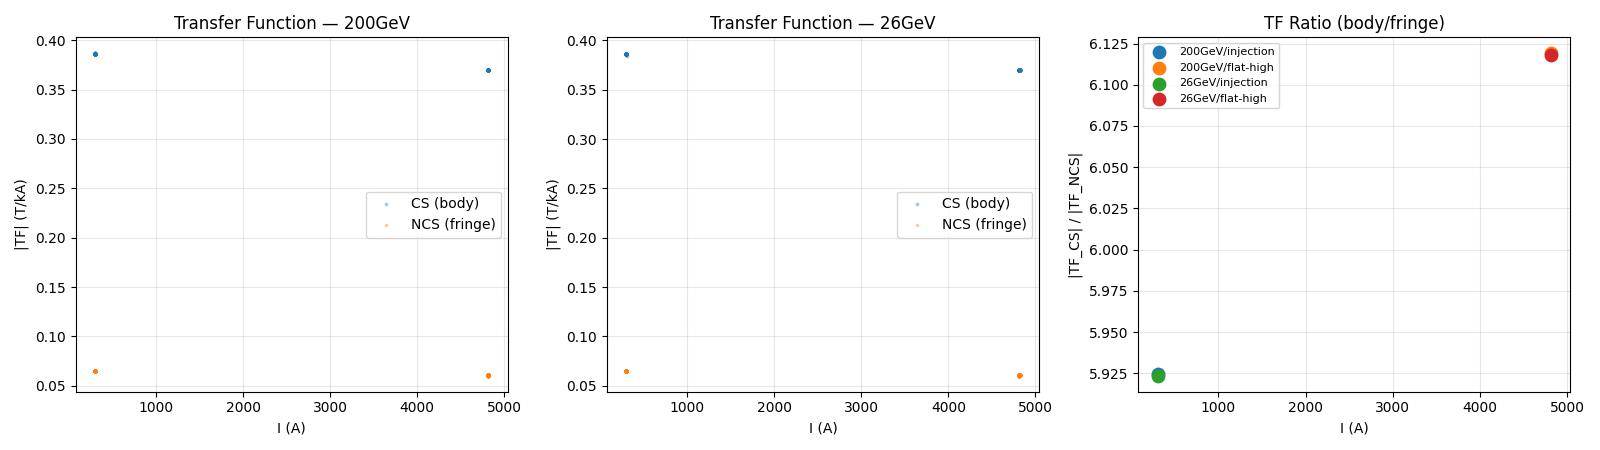

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, energy in enumerate(ENERGIES):
    ax = axes[i]
    for seg in SEGMENTS:
        role = 'body' if seg == SEG_BODY else 'fringe'
        df = settled[(energy, seg)]
        ax.scatter(df['I_mean_A'], df['TF_TperkA'].abs(), s=3, alpha=0.3, label=f'{seg} ({role})')
    ax.set_xlabel('I (A)')
    ax.set_ylabel('|TF| (T/kA)')
    ax.set_title(f'Transfer Function — {energy}')
    ax.legend()

# TF ratio plot (body / fringe)
ax = axes[2]
for energy in ENERGIES:
    for lbl in LABELS:
        tf_body = seg_summary[(seg_summary['energy']==energy) & (seg_summary['segment']==SEG_BODY) & (seg_summary['label']==lbl)]['TF_TperkA'].values
        tf_fringe = seg_summary[(seg_summary['energy']==energy) & (seg_summary['segment']==SEG_FRINGE) & (seg_summary['label']==lbl)]['TF_TperkA'].values
        if len(tf_body) > 0 and len(tf_fringe) > 0 and tf_fringe[0] != 0:
            I_mean = seg_summary[(seg_summary['energy']==energy) & (seg_summary['segment']==SEG_BODY) & (seg_summary['label']==lbl)]['I_mean_A'].values[0]
            ratio = abs(tf_body[0]) / abs(tf_fringe[0])
            ax.scatter(I_mean, ratio, s=80, marker='o', label=f'{energy}/{lbl}', zorder=5)

ax.set_xlabel('I (A)')
ax.set_ylabel(f'|TF_{SEG_BODY}| / |TF_{SEG_FRINGE}|')
ax.set_title('TF Ratio (body/fringe)')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

---
## 5. Integrated Field Estimation

### What the rotating coil actually measures

The rotating coil has a sensitive length `L_coil = 470 mm` (inside a 480 mm
mechanical housing). It does **not** measure the field at a point — it measures
the field **averaged over its sensitive length**:

$$B_{\text{coil}} = \frac{1}{L_{\text{coil}}} \int_{z_1}^{z_2} B(z) \, dz$$

So `B_coil × L_coil` gives the field integral over the coil's 470 mm sensitive span.

The same applies to every harmonic: the coil measures `C_n` averaged over its length.

### The physical setup

The MBB yoke is 6200 mm long. At one end, two segments are mounted in a
1060 mm assembly: each segment is 480 mm mechanically (470 mm sensitive),
with a **100 mm gap** between them.

The fringe coil straddles the yoke end: approximately **1/3 inside** and
**2/3 outside**:

```
      yoke iron (6200 mm)
    ┌──────────────────────────────────────────────────────────────┐
    │                              ┌────────┐ 100mm ┌────┬───────┤│
    │                              │  body  │  gap  │1/3 │       ││ ← fringe coil:
    │                              │  coil  │       │    │       ││   1/3 inside, 2/3 outside
    │                              │ 470mm  │       │    │───────┤├──
    │                              │(480mec)│       │    │       ││  2/3 outside (~313 mm)
    │                              └────────┘       └────┘       ││
    └──────────────────────────────────────────────────────────────┘
```

- **Body coil** (470 mm sensitive) — entirely inside the yoke, sees uniform main field
- **Gap** (100 mm) — inside the yoke, uniform field region (not measured, extrapolated)
- **Fringe coil** (470 mm sensitive) — straddles the yoke end: 1/3 inside, 2/3 outside

### The integration model

We want the **total** integrated field over the full magnet (including both fringes):

$$\int_{-\infty}^{+\infty} B(z) \, dz$$

We partition the magnet into three non-overlapping regions:

```
|← fringe →|←─── body exclusive ───→|← fringe' →|
  L_coil         L_body_excl            L_coil
```

The fringe coil already integrates the field over its full 470 mm span (including
the 1/3 inside the yoke). So we subtract the fringe-covered parts from L_yoke to
get the body-exclusive region, then use B_body for the remainder:

$$L_{\text{body,excl}} = L_{\text{yoke}} - 2 \times f_{\text{inside}} \times L_{\text{coil}} = 6.200 - 2 \times \tfrac{1}{3} \times 0.470 = 5.887\text{ m}$$

$$N_{\text{body,equiv}} = L_{\text{body,excl}} / L_{\text{coil}} = 5.887 / 0.470 \approx 12.52$$

**The 100 mm gap between segments** falls inside L_body_excl. It is in the
uniform field region of the yoke, so it is correctly valued at B_body in the
extrapolation. The gap does not change the formula.

**Key assumption: the field is uniform inside the yoke.** Since the body coil
is positioned in the uniform region, and the MBB field is extremely uniform over
the central ~5+ m (confirmed by NMR), we can extrapolate:

$$\int_{\text{body}} B(z) \, dz \;\approx\; B_{\text{body}} \times L_{\text{body,excl}}$$

**Symmetry assumption:** Both ends of the magnet have the same fringe field.
We only measure one end, so we assume the other is identical:

$$\int_{\text{fringes}} B(z) \, dz \;\approx\; 2 \times B_{\text{fringe}} \times L_{\text{coil}}$$

**Fringe tail fully captured:** The outside portion of the fringe coil extends
~313 mm beyond the yoke end, which is ~6 full apertures (52 mm half-gap). At
that distance, the fringe field has decayed to ~exp(-6π) ≈ 10⁻⁸ of B_body
(and higher multipoles decay even faster as exp(-nπz/a)). So the fringe coil
captures the entire fringe tail — no significant field is missed beyond it.

### Final formulas

$$B_{\text{int}} = B_{\text{body}} \times L_{\text{body,excl}} + 2 \times B_{\text{fringe}} \times L_{\text{coil}}$$

$$L_{\text{mag}} = \frac{B_{\text{int}}}{B_{\text{body}}} = L_{\text{body,excl}} + 2 \times L_{\text{coil}} \times \frac{B_{\text{fringe}}}{B_{\text{body}}}$$

### Why L_mag < L_yoke

With `f_inside = 1/3`, the model gives L_mag ≈ 6.04 m, which is **less than**
L_yoke = 6.200 m. This is genuinely physical:

- Each fringe coil contributes `L_coil × B_fringe/B_body` of equivalent body length.
  At injection: `0.470 × 0.169 = 0.079 m` per end (0.159 m total).
- We carved out `2 × f × L_coil = 0.313 m` of body-level length for them.
- Net: the fringe contribution falls ~0.155 m short of the body it replaced.

The fringe coil sees average field of only ~17% of B_body: the field drops from
B_body to zero over just ~2–3 apertures (100–150 mm), so most of the 470 mm
fringe span sees very weak field. The fringe regions "cost" equivalent length
rather than adding it.

Note: the previous version of this notebook used `f_inside = 0` and `L_yoke = 6.26 m`,
which gave L_mag > L_yoke. That was an artifact of double-counting: the body
integral was extrapolated over the full yoke including the part covered by the
fringe coil, overcounting that region at body-level field.

### Limitations

1. **Uniform body assumption**: valid for the MBB (long, unsaturated dipole).
   Would break for short magnets or near saturation where the field becomes
   non-uniform along z.
2. **Symmetric fringes**: we measure only one end. The two ends may differ
   slightly due to different end-plate geometry, connections, etc.
3. **Piecewise-constant model**: the real B(z) is continuous; we approximate
   it with 2 values. The sensitivity sweep (Section 8) quantifies the
   uncertainty range for `f_inside`.

In [6]:
def compute_integrated_field(B_body, B_fringe, L_yoke, L_coil, fringe_inside_fraction):
    """Compute integrated field and magnetic length.
    
    Assumes symmetric magnet: both ends have the same fringe field.
    
    Parameters
    ----------
    B_body : float
        Field in the uniform body region (T).
    B_fringe : float
        Field in the fringe region (T).
    L_yoke : float
        Total yoke length (m).
    L_coil : float
        Coil sensitive length (m).
    fringe_inside_fraction : float
        Fraction of the fringe coil inside the yoke (0..1).
    
    Returns
    -------
    dict with B_int (T*m), L_mag (m), L_body_excl (m), N_body_equiv
    """
    L_body_excl = L_yoke - 2 * fringe_inside_fraction * L_coil
    B_int = B_body * L_body_excl + 2 * B_fringe * L_coil
    L_mag = B_int / B_body if B_body != 0 else np.nan
    N_body_equiv = L_body_excl / L_coil
    return {'B_int_Tm': B_int, 'L_mag_m': L_mag, 'L_body_excl_m': L_body_excl, 'N_body_equiv': N_body_equiv}

In [7]:
int_rows = []

for energy in ENERGIES:
    for lbl in LABELS:
        body_mask = (seg_summary['energy']==energy) & (seg_summary['segment']==SEG_BODY) & (seg_summary['label']==lbl)
        fringe_mask = (seg_summary['energy']==energy) & (seg_summary['segment']==SEG_FRINGE) & (seg_summary['label']==lbl)
        
        if not body_mask.any() or not fringe_mask.any():
            continue
        
        B_body = abs(seg_summary.loc[body_mask, 'B1_T'].values[0])
        B_fringe = abs(seg_summary.loc[fringe_mask, 'B1_T'].values[0])
        I_mean = seg_summary.loc[body_mask, 'I_mean_A'].values[0]
        TF_body = abs(seg_summary.loc[body_mask, 'TF_TperkA'].values[0])
        TF_fringe = abs(seg_summary.loc[fringe_mask, 'TF_TperkA'].values[0])
        
        res = compute_integrated_field(B_body, B_fringe, L_YOKE, L_COIL, FRINGE_INSIDE_FRACTION)
        
        TF_int = res['B_int_Tm'] / (I_mean / 1000)  # T*m/kA
        
        int_rows.append({
            'energy': energy, 'label': lbl,
            'I_A': I_mean,
            'B_body_T': B_body, 'B_fringe_T': B_fringe,
            'seg_body': SEG_BODY, 'seg_fringe': SEG_FRINGE,
            'TF_body': TF_body, 'TF_fringe': TF_fringe,
            **res,
            'TF_int_TmperkA': TF_int,
        })

int_df = pd.DataFrame(int_rows)
display(int_df.round(6))

print(f"\nGeometry: L_body_excl = {int_df['L_body_excl_m'].iloc[0]:.4f} m, "
      f"N_body_equiv = {int_df['N_body_equiv'].iloc[0]:.2f}")

,energy,label,I_A,B_body_T,B_fringe_T,seg_body,seg_fringe,TF_body,TF_fringe,B_int_Tm,L_mag_m,L_body_excl_m,N_body_equiv,TF_int_TmperkA
0,200GeV,injection,300.903540,0.116255,0.019622,CS,NCS,0.386352,0.065212,0.702797,6.045328,5.886667,12.524823,2.335622
1,200GeV,flat-high,4814.559700,1.781715,0.291179,CS,NCS,0.370068,0.060479,10.762071,6.040287,5.886667,12.524823,2.235318
2,26GeV,injection,300.917556,0.116255,0.019625,CS,NCS,0.386336,0.065219,0.702804,6.045349,5.886667,12.524823,2.335537
3,26GeV,flat-high,4814.572478,1.781749,0.291240,CS,NCS,0.370074,0.060491,10.762328,6.040316,5.886667,12.524823,2.235365



Geometry: L_body_excl = 5.8867 m, N_body_equiv = 12.52


---
## 6. Magnetic Length

L_mag = B_int / B_body. Compare at injection vs flat-top to see saturation effect.

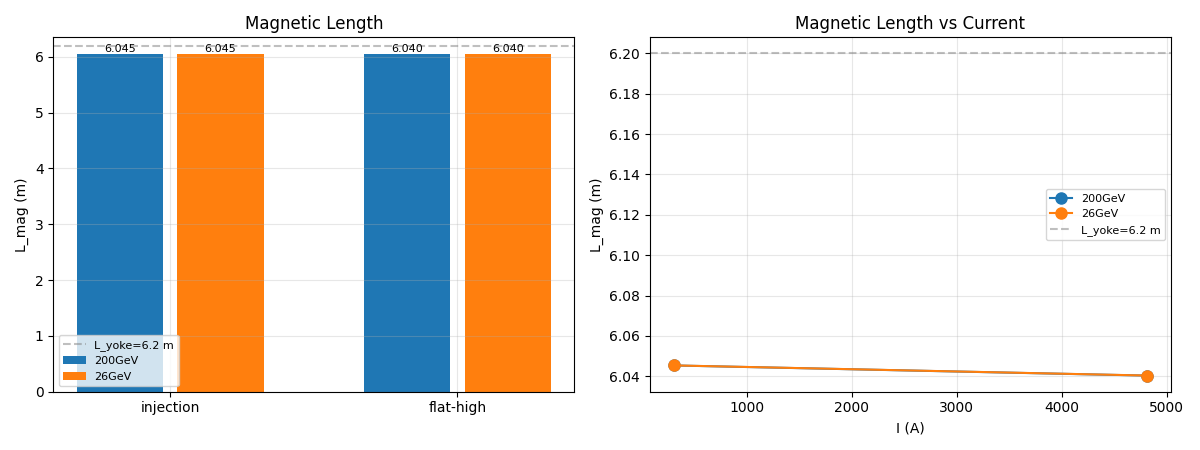

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar chart: L_mag at injection vs flat-top
ax = axes[0]
for i, energy in enumerate(ENERGIES):
    sub = int_df[int_df['energy'] == energy]
    x = np.arange(len(sub))
    bars = ax.bar(x + i * 0.35, sub['L_mag_m'], 0.3, label=energy)
    for bar, lbl in zip(bars, sub['label']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(np.arange(len(LABELS)) + 0.175)
ax.set_xticklabels(LABELS)
ax.set_ylabel('L_mag (m)')
ax.set_title('Magnetic Length')
ax.axhline(L_YOKE, color='gray', ls='--', alpha=0.5, label=f'L_yoke={L_YOKE} m')
ax.legend(fontsize=8)

# L_mag vs current
ax = axes[1]
for energy in ENERGIES:
    sub = int_df[int_df['energy'] == energy]
    ax.plot(sub['I_A'], sub['L_mag_m'], 'o-', label=energy, markersize=8)

ax.axhline(L_YOKE, color='gray', ls='--', alpha=0.5, label=f'L_yoke={L_YOKE} m')
ax.set_xlabel('I (A)')
ax.set_ylabel('L_mag (m)')
ax.set_title('Magnetic Length vs Current')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

---
## 7. Integrated Harmonics

### Why we can't just average the b_n values

The body has `b3 ≈ -0.2 units` and the fringe has `b3 ≈ 5.2 units`. You might
think the integrated b3 should be somewhere in between, but that's wrong because
**b_n is a ratio** (`C_n / C_1 × 10⁴`), and the two segments have very different C_1.

The fringe b3 is 25× larger than the body b3, but the fringe **field** is 6× weaker.
In absolute Tesla, the fringe C_3 is actually much smaller than the body C_3.
The large fringe b_n comes from dividing by a small B1, not from a large sextupole.

### Correct procedure: integrate in Tesla, then re-normalize

1. **Convert b_n (units) → C_n (Tesla)** per segment, using that segment's B1:

   $$C_n = b_n \times \frac{B_1}{10000}$$

2. **Integrate C_n along z** using the same geometric model as for B1:

   $$\int C_n \, dz = C_{n,\text{body}} \times L_{\text{body,excl}} + 2 \times C_{n,\text{fringe}} \times L_{\text{coil}}$$

3. **Re-normalize to get integrated b_n** (units), using the integrated B1:

   $$b_{n,\text{int}} = \frac{\int C_n \, dz}{\int B_1 \, dz} \times 10000 = \frac{\int C_n \, dz}{B_{\text{int}}} \times 10000$$

The integrated b_n tells you the effective multipole content that a beam
traversing the full magnet would experience.

### Why the integrated b_n ≈ body b_n

Since `L_body_excl ≫ 2 × L_coil` (~5.9 m vs 0.94 m) **and** `B1_body ≫ B1_fringe`,
the body contribution dominates both numerator and denominator:

$$b_{n,\text{int}} \;\approx\; \frac{C_{n,\text{body}} \times L_{\text{body}}}{B_{1,\text{body}} \times L_{\text{body}}} \times 10000 = b_{n,\text{body}}$$

The fringe is a small correction. This is a good sanity check of the results below.

In [9]:
def compute_integrated_harmonics(avgs_body, avgs_fringe, B_body, B_fringe, B_int,
                                  L_body_excl, L_coil, label, harmonics=HARMONICS):
    """Compute integrated harmonics for one current level."""
    rows = []
    for n in harmonics:
        bn_col = f'b{n}_units'
        an_col = f'a{n}_units'
        
        # Extract mean values
        bn_body = avgs_body.loc[label, (bn_col, 'mean')] if bn_col in avgs_body.columns.get_level_values(0) else 0
        bn_fringe = avgs_fringe.loc[label, (bn_col, 'mean')] if bn_col in avgs_fringe.columns.get_level_values(0) else 0
        an_body = avgs_body.loc[label, (an_col, 'mean')] if an_col in avgs_body.columns.get_level_values(0) else 0
        an_fringe = avgs_fringe.loc[label, (an_col, 'mean')] if an_col in avgs_fringe.columns.get_level_values(0) else 0
        
        # Convert to Tesla
        Cn_body = bn_body * B_body / 10000
        Cn_fringe = bn_fringe * B_fringe / 10000
        Sn_body = an_body * B_body / 10000
        Sn_fringe = an_fringe * B_fringe / 10000
        
        # Integrate
        Cn_int = Cn_body * L_body_excl + 2 * Cn_fringe * L_coil
        Sn_int = Sn_body * L_body_excl + 2 * Sn_fringe * L_coil
        
        # Re-normalize
        bn_int = Cn_int / B_int * 10000 if B_int != 0 else np.nan
        an_int = Sn_int / B_int * 10000 if B_int != 0 else np.nan
        
        rows.append({
            'n': n,
            'bn_body': bn_body, 'bn_fringe': bn_fringe, 'bn_int': bn_int,
            'an_body': an_body, 'an_fringe': an_fringe, 'an_int': an_int,
            'Cn_body_T': Cn_body, 'Cn_fringe_T': Cn_fringe, 'Cn_int_Tm': Cn_int,
            'Sn_body_T': Sn_body, 'Sn_fringe_T': Sn_fringe, 'Sn_int_Tm': Sn_int,
        })
    return pd.DataFrame(rows)

In [10]:
# Compute integrated harmonics for all energy/label combinations
int_harmonics = {}  # (energy, label) -> DataFrame

for _, row in int_df.iterrows():
    energy, lbl = row['energy'], row['label']
    avgs_body = avgs[(energy, SEG_BODY)]
    avgs_fringe = avgs[(energy, SEG_FRINGE)]
    
    ih = compute_integrated_harmonics(
        avgs_body, avgs_fringe,
        row['B_body_T'], row['B_fringe_T'], row['B_int_Tm'],
        row['L_body_excl_m'], L_COIL, lbl
    )
    ih['energy'] = energy
    ih['label'] = lbl
    int_harmonics[(energy, lbl)] = ih

# Show injection result for 200 GeV
display(int_harmonics[('200GeV', 'injection')][['n', 'bn_body', 'bn_fringe', 'bn_int', 'an_body', 'an_fringe', 'an_int']].round(3))

,n,bn_body,bn_fringe,bn_int,an_body,an_fringe,an_int
0,2,0.021,1.601,0.063,-0.414,9.065,-0.165
1,3,-0.226,5.171,-0.084,-0.114,-0.446,-0.123
2,4,-0.036,0.211,-0.029,0.049,0.662,0.066
3,5,-0.018,0.359,-0.008,0.001,0.197,0.006
4,6,0.011,0.054,0.012,0.001,0.060,0.002
5,7,0.073,0.252,0.078,0.038,0.410,0.048
6,8,0.011,-0.123,0.007,-0.006,-0.062,-0.007
7,9,-0.127,-0.259,-0.131,0.006,-0.082,0.004
8,10,-0.002,-0.016,-0.003,-0.025,-0.048,-0.026
9,11,0.170,0.085,0.167,0.002,0.110,0.005


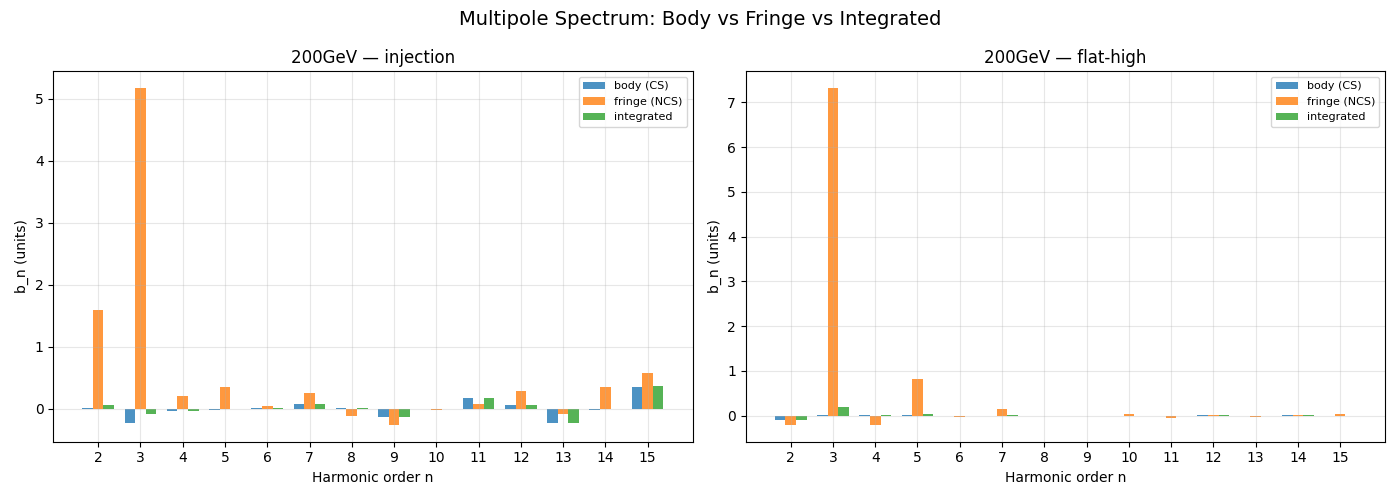

In [11]:
# Multipole spectrum plot: body vs fringe vs integrated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (energy, lbl) in enumerate([('200GeV', 'injection'), ('200GeV', 'flat-high')]):
    ax = axes[i]
    ih = int_harmonics[(energy, lbl)]
    x = ih['n']
    w = 0.25
    ax.bar(x - w, ih['bn_body'], w, label=f'body ({SEG_BODY})', alpha=0.8)
    ax.bar(x, ih['bn_fringe'], w, label=f'fringe ({SEG_FRINGE})', alpha=0.8)
    ax.bar(x + w, ih['bn_int'], w, label='integrated', alpha=0.8)
    ax.set_xlabel('Harmonic order n')
    ax.set_ylabel('b_n (units)')
    ax.set_title(f'{energy} — {lbl}')
    ax.set_xticks(x)
    ax.legend(fontsize=8)

fig.suptitle('Multipole Spectrum: Body vs Fringe vs Integrated', fontsize=14)
fig.tight_layout()
plt.show()

---
## 7b. Harmonic Spectrum Quality Check

For a well-made dipole, the absolute harmonic coefficients `|C_n|` should **decay
with harmonic order n** (approximately as a power law). On a log-scale plot this
appears as a line sloping downward.

If high-order harmonics flatten out at some constant level, that floor is the
**measurement noise**. Only harmonics well above the noise floor carry physical
meaning; those at or below the floor are unreliable.

This check is especially important for the **fringe** segment, where B1 is 6×
weaker and the signal-to-noise ratio is inherently lower.

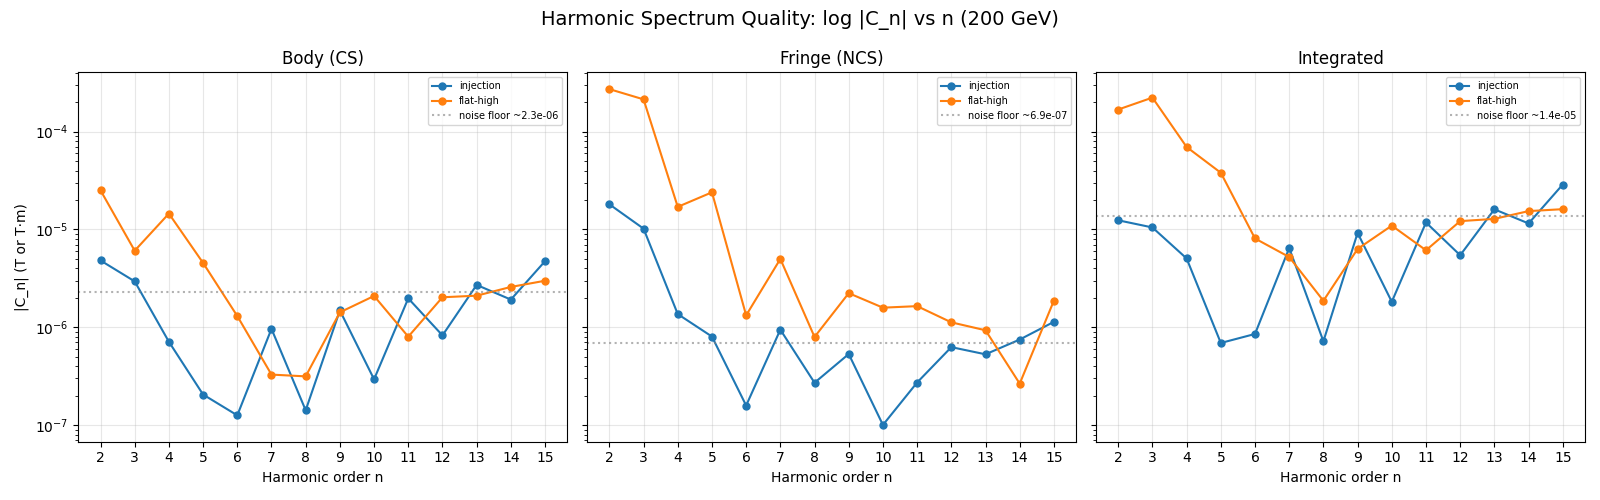

In [12]:
# Harmonic spectrum: log |C_n| vs n for body, fringe, and integrated (200 GeV)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for i, (seg_name, seg_label) in enumerate([
    (SEG_BODY, f'Body ({SEG_BODY})'),
    (SEG_FRINGE, f'Fringe ({SEG_FRINGE})'),
    ('integrated', 'Integrated'),
]):
    ax = axes[i]
    for lbl in LABELS:
        ih = int_harmonics[('200GeV', lbl)]
        if seg_name == 'integrated':
            Cn = np.sqrt(ih['Cn_int_Tm']**2 + ih['Sn_int_Tm']**2)
        elif seg_name == SEG_BODY:
            Cn = np.sqrt(ih['Cn_body_T']**2 + ih['Sn_body_T']**2)
        else:
            Cn = np.sqrt(ih['Cn_fringe_T']**2 + ih['Sn_fringe_T']**2)
        ax.semilogy(ih['n'], Cn.clip(lower=1e-20), 'o-', label=lbl, markersize=5)

    # Noise floor estimate: median of n=12..15
    ih_inj = int_harmonics[('200GeV', 'injection')]
    if seg_name == 'integrated':
        Cn_ref = np.sqrt(ih_inj['Cn_int_Tm']**2 + ih_inj['Sn_int_Tm']**2)
    elif seg_name == SEG_BODY:
        Cn_ref = np.sqrt(ih_inj['Cn_body_T']**2 + ih_inj['Sn_body_T']**2)
    else:
        Cn_ref = np.sqrt(ih_inj['Cn_fringe_T']**2 + ih_inj['Sn_fringe_T']**2)
    noise_floor = Cn_ref[ih_inj['n'] >= 12].median()
    ax.axhline(noise_floor, color='gray', ls=':', alpha=0.6, label=f'noise floor ~{noise_floor:.1e}')

    ax.set_xlabel('Harmonic order n')
    if i == 0:
        ax.set_ylabel('|C_n| (T or T·m)')
    ax.set_title(seg_label)
    ax.legend(fontsize=7)
    ax.set_xticks(ih['n'])

fig.suptitle('Harmonic Spectrum Quality: log |C_n| vs n (200 GeV)', fontsize=14)
fig.tight_layout()
plt.show()

**Interpretation:** If the last few harmonics (n = 12-15) cluster at the same level
and the curve flattens, that level is the measurement noise floor. Only harmonics
well above this floor (by at least ~10x) carry reliable physical information.

The **body** segment should show clear decay (high SNR). The **fringe** segment
will be noisier because B1 is 6x weaker, so the noise floor is relatively higher.
The **integrated** spectrum is dominated by the body contribution.

---
## 8. Geometry Sensitivity

Sweep `fringe_inside_fraction` from 0.0 to 0.5. Check how L_mag, B_int, and integrated b3 change.

In [13]:
fif_range = np.linspace(0.0, 0.5, 51)

sensitivity_rows = []
for energy in ENERGIES:
    for lbl in LABELS:
        base = int_df[(int_df['energy']==energy) & (int_df['label']==lbl)]
        if base.empty:
            continue
        B_body = base['B_body_T'].values[0]
        B_fringe = base['B_fringe_T'].values[0]
        
        # Get b3 values for integrated harmonics
        avgs_body = avgs[(energy, SEG_BODY)]
        avgs_fringe = avgs[(energy, SEG_FRINGE)]
        b3_body = avgs_body.loc[lbl, ('b3_units', 'mean')]
        b3_fringe = avgs_fringe.loc[lbl, ('b3_units', 'mean')]
        C3_body = b3_body * B_body / 10000
        C3_fringe = b3_fringe * B_fringe / 10000
        
        for fif in fif_range:
            res = compute_integrated_field(B_body, B_fringe, L_YOKE, L_COIL, fif)
            L_be = res['L_body_excl_m']
            B_int = res['B_int_Tm']
            C3_int = C3_body * L_be + 2 * C3_fringe * L_COIL
            b3_int = C3_int / B_int * 10000 if B_int != 0 else np.nan
            sensitivity_rows.append({
                'energy': energy, 'label': lbl, 'fringe_inside_fraction': fif,
                'B_int_Tm': B_int, 'L_mag_m': res['L_mag_m'], 'b3_int': b3_int,
            })

sens_df = pd.DataFrame(sensitivity_rows)
print(f"Sensitivity sweep: {len(sens_df)} rows")

Sensitivity sweep: 204 rows


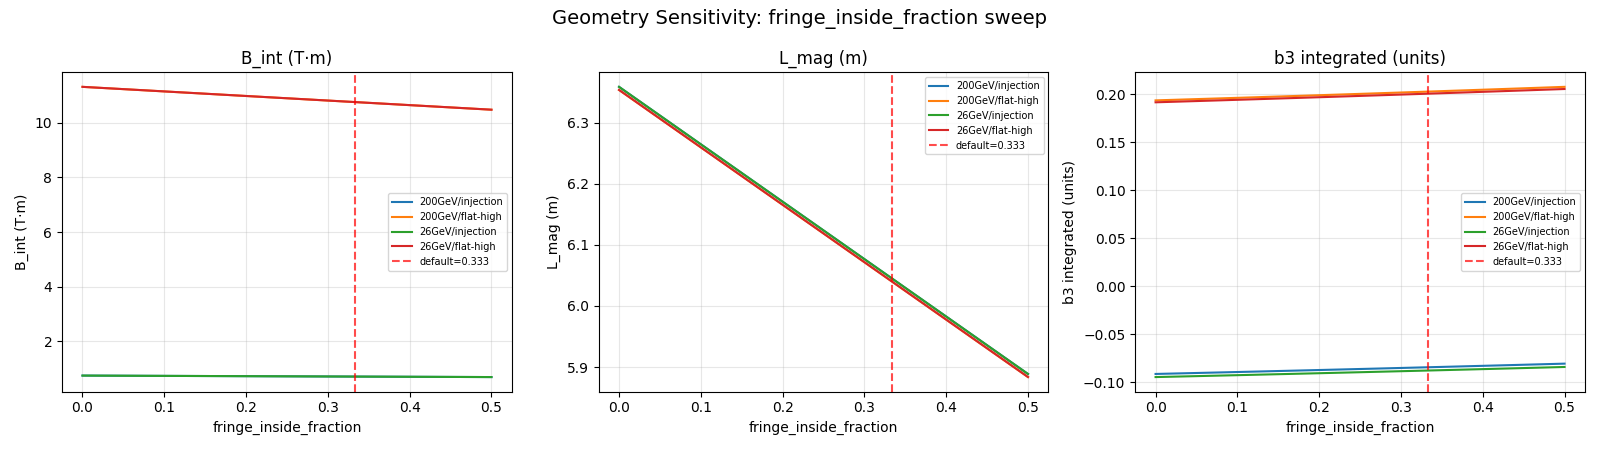

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Geometry Sensitivity: fringe_inside_fraction sweep', fontsize=14)

plot_combos = [('B_int_Tm', 'B_int (T·m)'), ('L_mag_m', 'L_mag (m)'), ('b3_int', 'b3 integrated (units)')]

for i, (col, ylabel) in enumerate(plot_combos):
    ax = axes[i]
    for energy in ENERGIES:
        for lbl in LABELS:
            sub = sens_df[(sens_df['energy']==energy) & (sens_df['label']==lbl)]
            if sub.empty: continue
            ax.plot(sub['fringe_inside_fraction'], sub[col], label=f'{energy}/{lbl}')
    ax.axvline(FRINGE_INSIDE_FRACTION, color='red', ls='--', alpha=0.7,
               label=f'default={FRINGE_INSIDE_FRACTION:.3f}')
    ax.set_xlabel('fringe_inside_fraction')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

---
## 9. Deliverables Table

Per current level: I, B_int, L_mag, TF_int, b2..b15 integrated.

In [15]:
deliv_rows = []
for _, row in int_df.iterrows():
    energy, lbl = row['energy'], row['label']
    ih = int_harmonics[(energy, lbl)]
    d = {
        'energy': energy, 'label': lbl,
        'I_A': row['I_A'],
        'B_int_Tm': row['B_int_Tm'],
        'L_mag_m': row['L_mag_m'],
        'TF_int_TmperkA': row['TF_int_TmperkA'],
    }
    for _, hr in ih.iterrows():
        d[f'b{int(hr["n"])}_int'] = hr['bn_int']
        d[f'a{int(hr["n"])}_int'] = hr['an_int']
    deliv_rows.append(d)

deliverables = pd.DataFrame(deliv_rows)
display(deliverables.round(4))

,energy,label,I_A,B_int_Tm,L_mag_m,TF_int_TmperkA,b2_int,a2_int,b3_int,a3_int,...,b11_int,a11_int,b12_int,a12_int,b13_int,a13_int,b14_int,a14_int,b15_int,a15_int
0,200GeV,injection,300.9035,0.7028,6.0453,2.3356,0.0625,-0.1649,-0.0845,-0.1227,...,0.1675,0.0046,0.0674,0.0382,-0.2275,-0.0201,-0.0016,-0.1638,0.3628,0.1900
1,200GeV,flat-high,4814.5597,10.7621,6.0403,2.2353,-0.0889,0.1284,0.2028,-0.0399,...,-0.0056,-0.0009,0.0112,0.0017,-0.0116,-0.0029,0.0051,-0.0134,0.0010,0.0149
2,26GeV,injection,300.9176,0.7028,6.0453,2.3355,0.0490,-0.1684,-0.0879,-0.1220,...,-0.0248,0.0096,0.0749,-0.0013,-0.0275,-0.0869,-0.0211,0.0369,0.0540,-0.1412
3,26GeV,flat-high,4814.5725,10.7623,6.0403,2.2354,-0.1039,0.1194,0.2007,-0.0397,...,0.0018,-0.0067,0.0197,0.0098,-0.0044,0.0031,-0.0021,-0.0006,0.0099,0.0119


---
## 10. CSV Export

In [16]:
out_dir = OUT_BASE / "integrated_field"
out_dir.mkdir(parents=True, exist_ok=True)

# 1. Integrated field summary
int_df.to_csv(out_dir / "integrated_field_summary.csv", index=False)
print(f"Saved: {out_dir / 'integrated_field_summary.csv'}")

# 2. Integrated harmonics (all energy/label combos)
all_ih = pd.concat(int_harmonics.values(), ignore_index=True)
all_ih.to_csv(out_dir / "integrated_harmonics.csv", index=False)
print(f"Saved: {out_dir / 'integrated_harmonics.csv'}")

# 3. Geometry sensitivity
sens_df.to_csv(out_dir / "geometry_sensitivity.csv", index=False)
print(f"Saved: {out_dir / 'geometry_sensitivity.csv'}")

# 4. Deliverables
deliverables.to_csv(out_dir / "deliverables.csv", index=False)
print(f"Saved: {out_dir / 'deliverables.csv'}")

Saved: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\integrated_field\integrated_field_summary.csv
Saved: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\integrated_field\integrated_harmonics.csv
Saved: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\integrated_field\geometry_sensitivity.csv
Saved: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\integrated_field\deliverables.csv


### Summary

#### Method

Two coil segments at one end of a 6200 mm magnet, in a 1060 mm assembly:
each 480 mm mechanical (470 mm sensitive), with a 100 mm gap between them.
One measures the uniform body field, the other measures the fringe.
The fringe coil straddles the yoke end (~1/3 inside, ~2/3 outside).

1. `L_body_excl = L_yoke - 2 × f_inside × L_coil` — yoke length not
   covered by fringe coils. The 100 mm gap falls inside this region
   (uniform field, extrapolated at B_body).
2. **Extrapolate** the body measurement over L_body_excl (justified
   because B is uniform inside a long dipole yoke — confirmed by NMR).
3. **Assume symmetric fringes** (only one end measured).
4. `B_int = B_body × L_body_excl + 2 × B_fringe × L_coil` — no double counting.
5. For harmonics: convert b_n → C_n (Tesla) per segment, integrate, re-normalize.

#### Geometry

| Parameter | Value |
|-----------|-------|
| L_yoke | 6200 mm |
| L_coil (sensitive) | 470 mm |
| L_seg (mechanical) | 480 mm |
| L_gap (between segments) | 100 mm (= 1060 - 2×480) |
| Total assembly | 1060 mm |
| f_inside (fringe inside fraction) | 1/3 |
| L_body_excl | 5887 mm |
| N_body_equiv (= L_body_excl / L_coil) | 12.52 |

#### L_mag < L_yoke — genuinely physical

L_mag ≈ 6.04 m < L_yoke = 6.200 m. This is genuinely physical:

- The fringe coil extends ~313 mm beyond the yoke end (~6 full apertures).
  At that distance, the fringe field has fully decayed — the entire tail
  is captured.
- Each fringe coil sees only ~17% of B_body on average, contributing
  ~0.079 m of equivalent body length per end (~0.159 m total).
- We carved out 0.313 m of body-level length for them. Net: the fringe
  regions "cost" ~0.155 m of equivalent length.

#### Assumptions and limitations

1. Uniform body field (valid for long, unsaturated MBB dipole).
2. Symmetric fringes (not verified — only one end measured).
3. f_inside = 1/3 (estimated). Sensitivity sweep in Section 8 shows the range.